In [ ]:
from utils import * 
import json 
from Bio.Align import PairwiseAligner
from fasta import FASTAFile
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from matplotlib.colors import ListedColormap
import networkx as nx
 
# bz_0_host_genome_id = 'SR-VP_Bioreactor_ck_bot_05_17_2025_Black_host_Methanoperedens_44_40'

%load_ext autoreload 
%autoreload 2

DATA_DIR = '../data/sr-vp'

# Note that when making the lists, matching annotations which contain only "rps3" results in false positives, as some proteins have descriptions which describe rps3-based 
# taxonomy are also flagged, e.g. "...organism_desc=Sibling to OP3 based on rpS3."

In [3]:
def load_coverm(path:str):
    '''coverm data has a column per sample and per metric. Columns are of the form {reads_path} {metric}.'''
    metrics = ['Trimmed Mean', 'Mean',  'Covered Bases', 'Covered Fraction', 'Variance', 'Read Count', 'RPKM', 'TPM', 'Length']
    column_pattern = r'(?P<sample_id>[A-Za-z0-9_]+) (?P<metric>.+)$'
    
    df = pd.read_csv(path, sep='\t')
    df = df.rename(columns={'Contig':'contig_id'})
    df = df.melt(id_vars='contig_id', var_name='column', value_name='value').reset_index()
    df = pd.concat([df.drop(columns=['column']).copy(), df['column'].str.extract(column_pattern)], axis=1)
    df = df[df.metric.isin(metrics)].copy() # Some weirdness with duplicate columns (e.g. Mean.1) being created, not sure why. 
    df['metric'] = df['metric'].apply(lambda metric : metric.replace(' ', '_').lower())
    df = df.pivot(values='value', columns='metric', index=['contig_id', 'sample_id']).reset_index()
    df.columns.name = ''
    return df

In [4]:
# Want to look at co-occurrence patterns of the two Betazoids we have in the SR-VP samples. 

# First need to look at what Methanoperedens are present. We have 77 complete and partial genomes https://ggkbase.berkeley.edu/MpSRVP/organisms
SRVP_SAMPLE_METADATA_DF = pd.read_csv('../data/sr-vp/sample_metadata.csv')
SRVP_SAMPLE_METADATA_DF = SRVP_SAMPLE_METADATA_DF[SRVP_SAMPLE_METADATA_DF.regime == 'Illumina'].copy()


In [5]:
def load_ggkbase_fasta(path:str):
    df = FASTAFile.from_file(path).to_df()
    df['project_id'] = [id_.split('|')[2] for id_ in df.index]
    df['gene_id'] = [id_.split('|')[0] for id_ in df.index]
    df['bin_id'] = [id_.split('|')[1] for id_ in df.index]
    df = df.set_index('gene_id')
    return df

In [6]:
# I don't necessarily trust the taxonomy assignments on ggKbase, particularly because they are not particulary detailed or standardized. 
# Instead, I did the following:
#   (1) Obtained all SR-VP rps3 nucleotide sequences assigned as archaeal, unkown, or eukaryotic using ggKbase lists (./data/archaea_rps3.fna). 
#   (2) Obtained all archaeal marker genes in the TIGR01008.fna file from the latest GTDB release (under genomic_files_all/ar53_marker_genes_all.tar.gz). 
#       The ID of each sequence is its corresponding genome. 
#   (3) Constructed a BLAST nucleotide database on biotite using the GTDB genes (n=20119). 
#   (4) Ran BLASTn against the GTDB database on biotite. blastn
#        -db /home/philippar/db/gtdb_archaea_rps3 -out archaea_rps3_blast-gtdb_archaea_rps3.tsv -query /home/philippar/betazoid/sr-vp/archaea_rps3.fna -outfmt "6 qseqid sseqid pident length evalue bitscore qstart qend sstart send" -max_hsps 1 -max_target_seqs 50
#   (5) Used the strongest BLASTn hit from GTDB to assign taxonomy to each rps3 sequence.  


In [7]:
archaea_rps3_df = load_ggkbase_fasta('../data/sr-vp/archaea_rps3.fna') # Obtained using the ggKbase lists utility, filtered for Archaeal and unknown taxonomy.
mp_srvp_rps3_df = load_ggkbase_fasta('../data/sr-vp/MpSRVP_rps3.faa')

print('Number of rps3 sequences assigned Archaeal or unknown taxonomy in SR-VP samples:', archaea_rps3_df.index.nunique())
print('Number of rps3 sequences identified in the MpSRVP project:', mp_srvp_rps3_df.index.nunique())
print('Number of rps3 sequences in the MpSRVP project assigned archaeal, unknown, or eukaryotic taxonomy:', mp_srvp_rps3_df.index.isin(archaea_rps3_df.index.values).sum())


Number of rps3 sequences assigned Archaeal or unknown taxonomy in SR-VP samples: 6793
Number of rps3 sequences identified in the MpSRVP project: 62
Number of rps3 sequences in the MpSRVP project assigned archaeal, unknown, or eukaryotic taxonomy: 62


In [8]:
BLAST_FIELDS = ['gene_id', 'subject_gene_id', 'percent_identity', 'alignment_length', 'e_value', 'bit_score', 'query_start', 'query_end', 'subject_start', 'subject_end']
GTDB_TAXONOMY_PATTERN = r'd__(?P<domain>[^;]+);p__(?P<phylum>[^;]+);c__(?P<class>[^;]+);o__(?P<order>[^;]+);f__(?P<family>[^;]+);g__(?P<genus>[^;]+);s__(?P<species>[^$]+)'

archaea_rps3_blast_df = pd.read_csv('../data/sr-vp/archaea_rps3_blast-gtdb_archaea_rps3.tsv', sep='\t', names=BLAST_FIELDS)
archaea_rps3_blast_df['gene_id'] = [gene_id.split('|')[0] for gene_id in archaea_rps3_blast_df.gene_id]
archaea_rps3_blast_df['subject_genome_id'] = archaea_rps3_blast_df.subject_gene_id
archaea_rps3_blast_df['subject_taxonomy'] = archaea_rps3_blast_df.subject_genome_id.map(pd.read_csv('../data/sr-vp/gtdb_archaea_taxonomy.tsv', sep='\t', index_col=0, names=['taxonomy']).taxonomy)
archaea_rps3_blast_df = pd.concat([archaea_rps3_blast_df, archaea_rps3_blast_df.subject_taxonomy.str.extract(GTDB_TAXONOMY_PATTERN)], axis=1)
archaea_rps3_blast_df = archaea_rps3_blast_df.sort_values('bit_score', ascending=False).copy() # So when duplicates are dropped, the strongest hit is retained.

filters = dict()
filters['short_alignment'] = archaea_rps3_blast_df.alignment_length < 100
filters['low_percent_identity'] = archaea_rps3_blast_df.percent_identity < 80 

archaea_rps3_blast_df = apply_filters(filters, archaea_rps3_blast_df)
assert np.all(mp_srvp_rps3_df.index.isin(archaea_rps3_blast_df.gene_id)), 'Methanoperedens from the MpSRVP project are not represented in the filtered BLAST output.'

taxonomy_cols = ['domain', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'percent_identity']
archaea_rps3_df = archaea_rps3_df.drop(columns=taxonomy_cols, errors='ignore')
archaea_rps3_df = archaea_rps3_df.merge(archaea_rps3_blast_df.drop_duplicates('gene_id').set_index('gene_id')[taxonomy_cols], how='left', left_index=True, right_index=True)
archaea_rps3_df['contig_id'] = ['_'.join(id_.split('_')[:-1]) for id_ in archaea_rps3_df.index]
archaea_rps3_df['has_blast_hit'] = archaea_rps3_df.index.isin(archaea_rps3_blast_df.gene_id.unique())
archaea_rps3_df['in_mp_srvp'] = archaea_rps3_df.index.isin(mp_srvp_rps3_df.index.values)
archaea_rps3_df['length'] = archaea_rps3_df.seq.apply(len)
assert np.all(mp_srvp_rps3_df.index.isin(archaea_rps3_blast_df.gene_id)), 'Methanoperedens from the MpSRVP project are not represented in the filtered BLAST output.'

filters = dict()
filters['not_methanoperedens'] = archaea_rps3_df.genus != 'Methanoperedens'
filters['partial_gene'] = archaea_rps3_df.seq.apply(len) < 600

mp_rps3_df = apply_filters(filters, archaea_rps3_df)

print('\nNumber of rps3 with a BLAST hit:', archaea_rps3_blast_df.gene_id.nunique())
print('Number of rps3 with no BLAST hits:', (~archaea_rps3_df.has_blast_hit).sum())
print('Number of Methanoperedens rps3:', len(mp_rps3_df))


apply_filters: 906 entries removed by short_alignment.
apply_filters: 30140 entries removed by low_percent_identity.
apply_filters: 6389 entries removed by not_methanoperedens.
apply_filters: 1276 entries removed by partial_gene.

Number of rps3 with a BLAST hit: 4041
Number of rps3 with no BLAST hits: 2752
Number of Methanoperedens rps3: 364


In [9]:
# Did a first pass of Methanoperedens abundance by clustering the filtered rps3 sequences at 98% identity (--cover-mode 5, -c 0.9) and using coverm to map. 
# However, this resulte in read counts which did not make sense (e.g. no reads mapping to a gene despite it being on a high-abundance contig in ggKbase). 
# I suspect the problem is related to mapping ambiguity, so adjusted my approach to the following. 
#   (1) Obtained the full contigs from the rps3 in mp_rps3_df from Shufei, along with the coverage and taxonomy (included in FASTA headers).
#   (2) Extended each rps3 gene beyond the ORF by between 100-500 bp, depending on the length of the source contig. 
#   (3) Used MMseqs to align and cluster all rps3 (for greater control over the clustering conditions). 
#   (4) Selected the longest representative sequence from each cluster and used bbmap to map reads, with the --ambiguous all flag. 

def load_mp_rps3_contigs(path:str='../data/sr-vp/mp_rps3_contigs.txt'):
    parse_header = lambda header : dict(zip(['id', 'contig_id', 'coverage', 'taxonomy'], header.split('|')))
    df = FASTAFile.from_file(path).to_df()
    df['description'] = df.index + df.description # The BioPython FASTA parser does not handle the descriptions correctly for this file. 
    df = df.reset_index(drop=True)
    df = pd.concat([df, pd.DataFrame.from_records(df.description.apply(parse_header))], axis=1)
    df['length'] = df.seq.apply(len)
    df = df.drop_duplicates('contig_id').set_index('contig_id')
    return df

mp_rps3_contigs_df = load_mp_rps3_contigs()
print('Minimum contig length:', mp_rps3_contigs_df.seq.apply(len).min())
print('Maximum contig length:', mp_rps3_contigs_df.seq.apply(len).max())

Minimum contig length: 1007
Maximum contig length: 4112728


In [10]:
delta = 500

for row in tqdm(mp_rps3_df.itertuples(), desc='Extending sequences beyond rps3 ORF.'):
    contig = mp_rps3_contigs_df.loc[row.contig_id].seq

    match_ = re.search(row.seq, contig)
    if match_ is None:
        contig = reverse_complement(contig)
        match_ = re.search(row.seq, contig)

    start, end = match_.start(), match_.end()
    start = max(start - delta, 0)
    end = min(end + delta, len(contig))
    
    mp_rps3_df.loc[row.Index, 'seq'] = contig[start:end]
    mp_rps3_df.loc[row.Index,'left_extension_length'] = match_.start() - start 
    mp_rps3_df.loc[row.Index,'right_extension_length'] = end - match_.end()

FASTAFile.from_df(mp_rps3_df).write('../data/sr-vp/mp_rps3.fna')

BIOTITE_MMSEQS_DIR = '/home/philippar/sr-vp/mmseqs'
MMSEQS_SEARCH_FIELDS = 'query,target,fident,alnlen,qcov,tcov,qstart,qend,tstart,tend,qlen,tlen'

cmd = f'\nmmseqs search {BIOTITE_MMSEQS_DIR}/db/mp_rps3/mp_rps3 {BIOTITE_MMSEQS_DIR}/db/mp_rps3/mp_rps3 {BIOTITE_MMSEQS_DIR}/db/mp_rps3.out/mp_rps3.out /home/philippar/tmp/ --search-type 3'
cmd += f'\nmmseqs convertalis {BIOTITE_MMSEQS_DIR}/db/mp_rps3/mp_rps3 {BIOTITE_MMSEQS_DIR}/db/mp_rps3/mp_rps3 {BIOTITE_MMSEQS_DIR}/db/mp_rps3.out/mp_rps3.out {BIOTITE_MMSEQS_DIR}/mp_rps3.tsv --format-output {MMSEQS_SEARCH_FIELDS}'
print(cmd)

Extending sequences beyond rps3 ORF.: 364it [00:00, 391.12it/s]


mmseqs search /home/philippar/sr-vp/mmseqs/db/mp_rps3/mp_rps3 /home/philippar/sr-vp/mmseqs/db/mp_rps3/mp_rps3 /home/philippar/sr-vp/mmseqs/db/mp_rps3.out/mp_rps3.out /home/philippar/tmp/ --search-type 3
mmseqs convertalis /home/philippar/sr-vp/mmseqs/db/mp_rps3/mp_rps3 /home/philippar/sr-vp/mmseqs/db/mp_rps3/mp_rps3 /home/philippar/sr-vp/mmseqs/db/mp_rps3.out/mp_rps3.out /home/philippar/sr-vp/mmseqs/mp_rps3.tsv --format-output query,target,fident,alnlen,qcov,tcov,qstart,qend,tstart,tend,qlen,tlen


In [11]:
# Using mmseqs easy-cluster poduced similar results, but this allows a bit more control over which alignments justify clustering.

mp_rps3_align_df = pd.read_csv('../data/sr-vp/mmseqs/mp_rps3.tsv', sep='\t', names=MMSEQS_SEARCH_FIELDS.split(','))

print('Number of query contigs:', mp_rps3_align_df['query'].nunique())
print('Number of alignments:', len(mp_rps3_align_df))
print('Maximum number of alignments:', mp_rps3_align_df['query'].nunique() **2, end='\n\n')

# Want any alignment with coverage < 100% to be at the end of one of the two sequences. 
delta = 3
mask = (mp_rps3_align_df.qstart < delta) | (mp_rps3_align_df.tstart < delta)
mask = mask | ((mp_rps3_align_df.qlen - mp_rps3_align_df.qend) < delta)
mask = mask | ((mp_rps3_align_df.tlen - mp_rps3_align_df.tend) < delta)

filters = dict()
filters['low_sequence_identity'] = mp_rps3_align_df.fident < 0.95
filters['self_alignment'] = mp_rps3_align_df['query'] == mp_rps3_align_df['target']
filters['incomplete_alignment'] = ~mask

mp_rps3_align_df = apply_filters(filters, mp_rps3_align_df)

edges = set()
for row in mp_rps3_align_df.itertuples():
    edges.add(tuple(sorted([row.query, row.target])))
nodes = mp_rps3_df.index.values

graph = nx.Graph()
graph.add_nodes_from(nodes)
graph.add_edges_from(edges)

clusters = sorted(list(nx.connected_components(graph)), key=len)[::-1]
cluster_id_map = {gene_id:i for i, cluster in enumerate(clusters) for gene_id in cluster}
print('\nNumber of clusters:', len(clusters))
print('Number of singleton clusters:', sum([len(cluster) == 1 for cluster in clusters]))

mp_rps3_df['cluster_id'] = mp_rps3_df.index.map(cluster_id_map)
mp_rps3_df['length'] = mp_rps3_df.seq.apply(len)

mp_reps_rps3_df = mp_rps3_df.sort_values('length', ascending=False).drop_duplicates('cluster_id')
mp_reps_rps3_df['genome_id'] = [f'mp_{i}' for i in mp_reps_rps3_df.cluster_id]
mp_reps_rps3_df = mp_reps_rps3_df.reset_index(drop=False).set_index('genome_id')


Number of query contigs: 364
Number of alignments: 109200
Maximum number of alignments: 132496

apply_filters: 102033 entries removed by low_sequence_identity.
apply_filters: 364 entries removed by self_alignment.
apply_filters: 2684 entries removed by incomplete_alignment.

Number of clusters: 43
Number of singleton clusters: 16


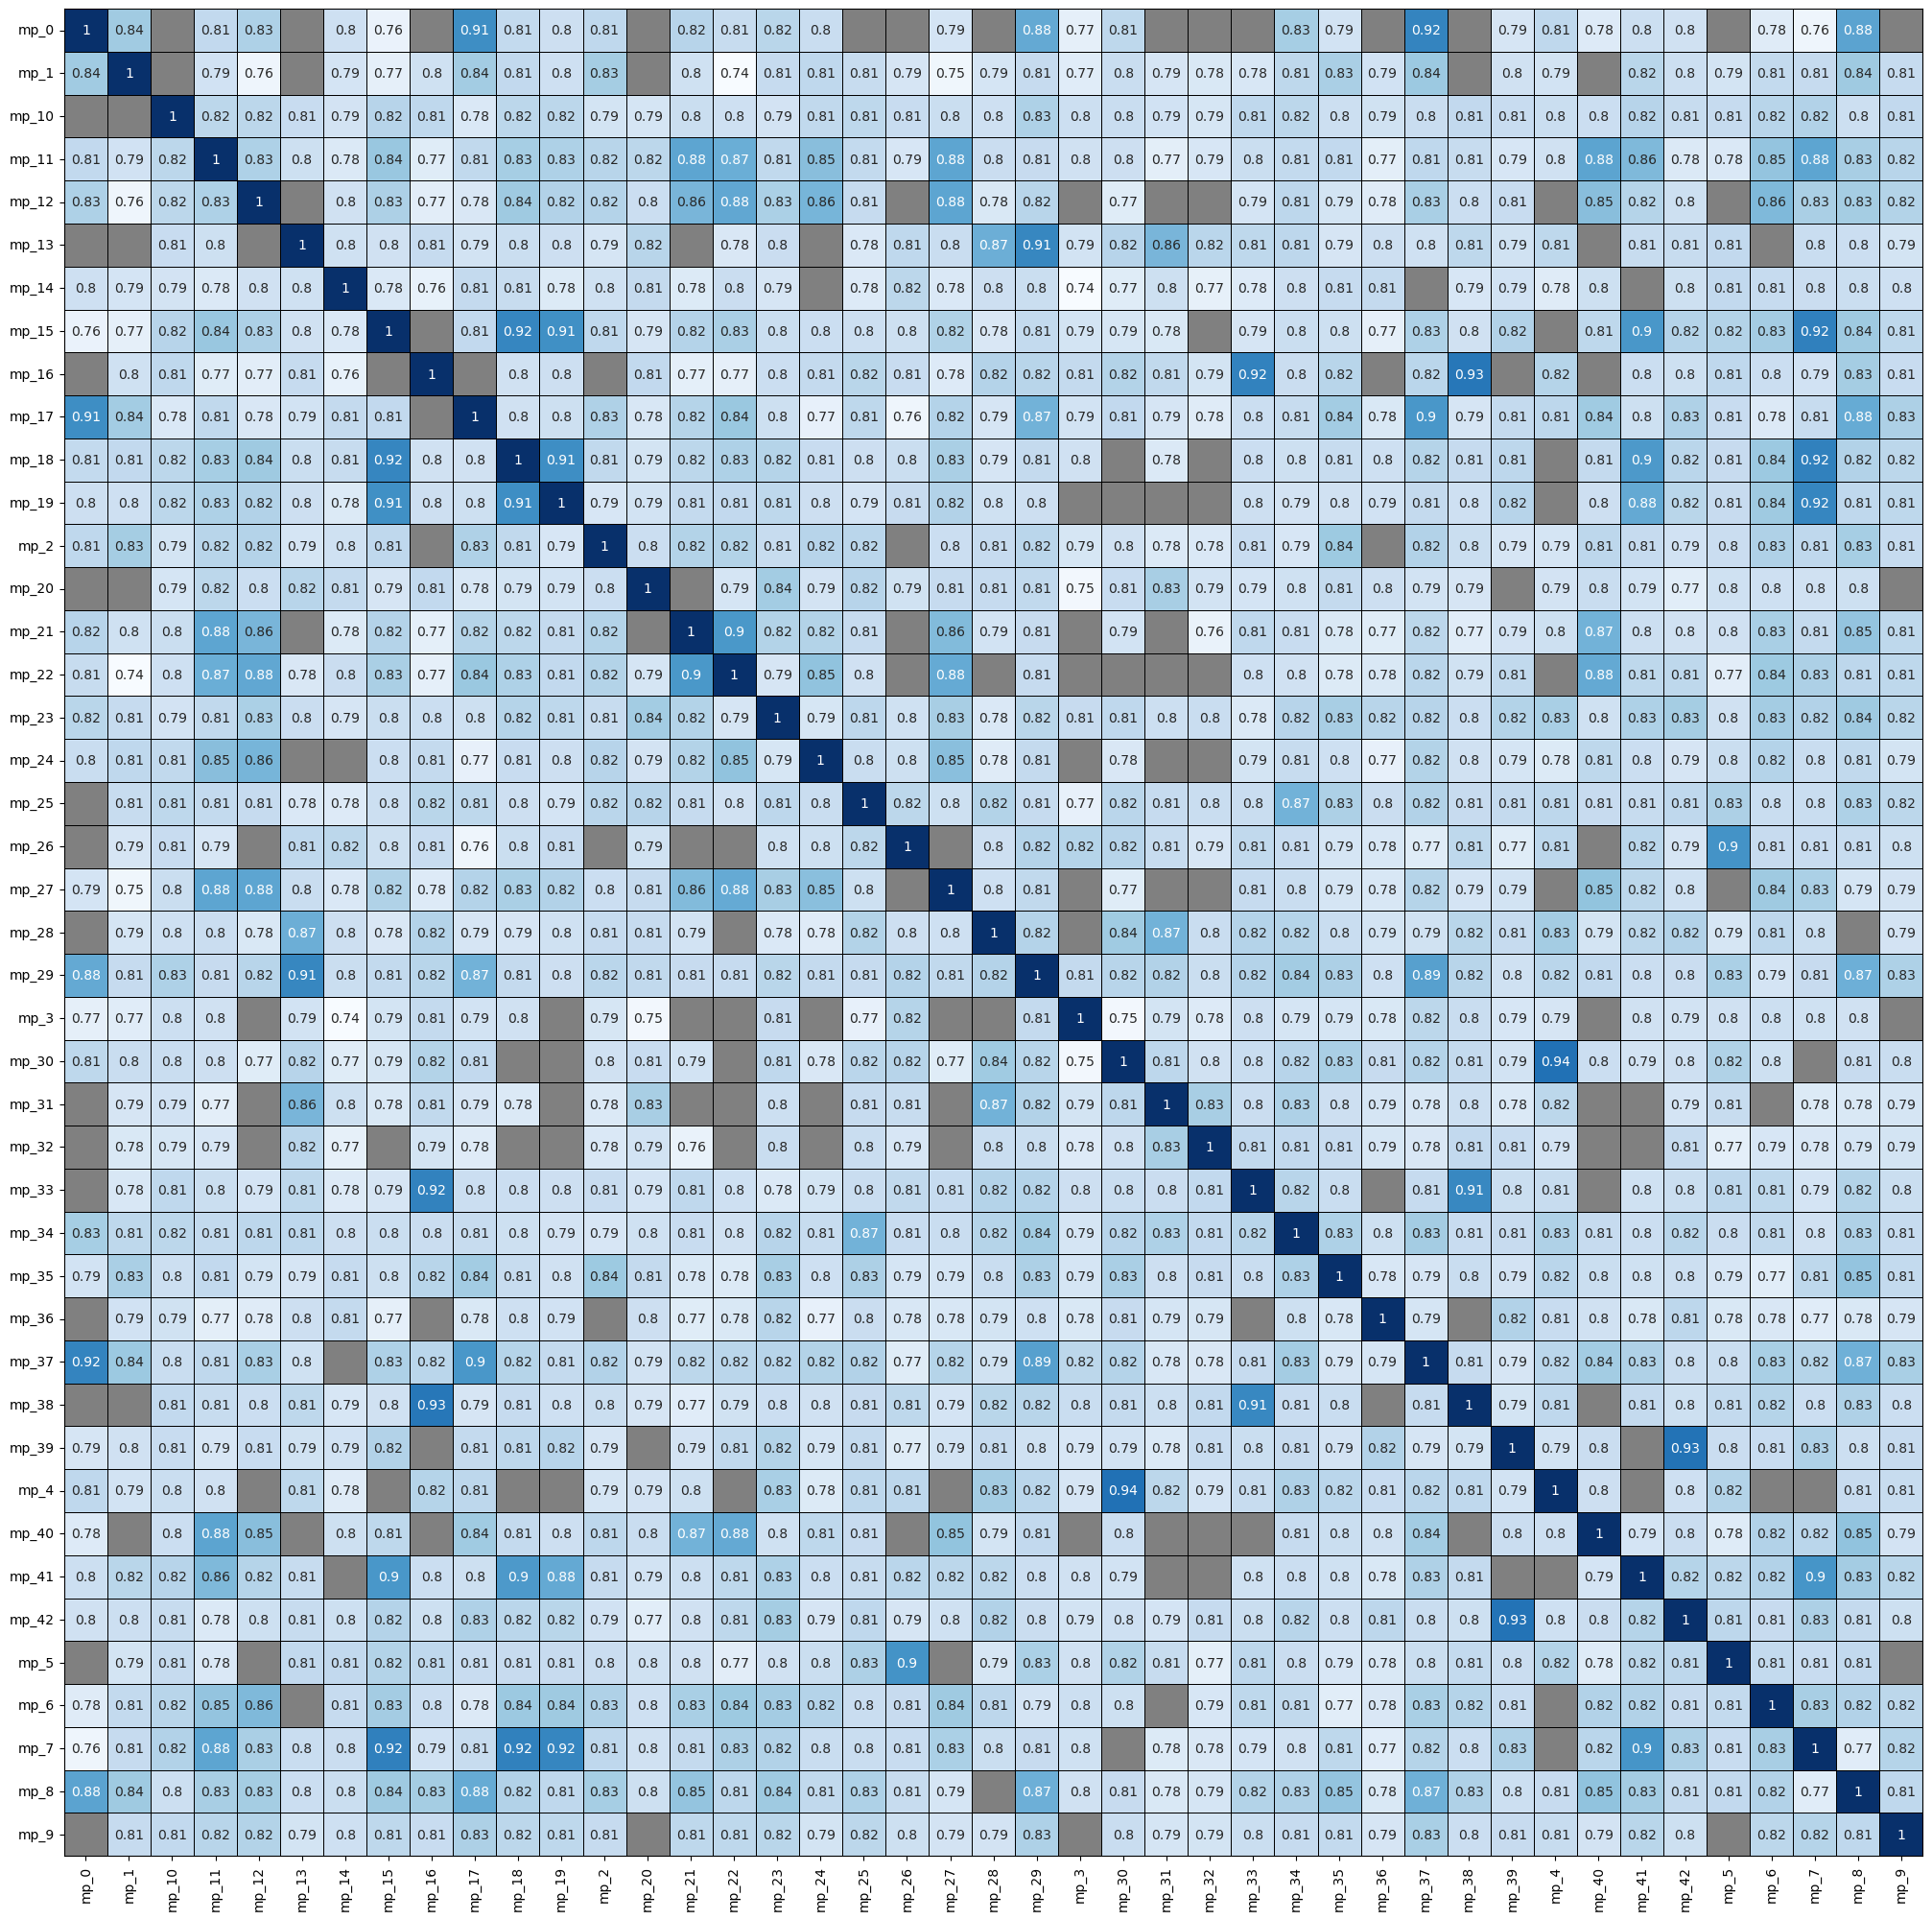

In [12]:
rep_gene_ids = mp_reps_rps3_df.gene_id.unique() # The representative gene IDs. 
gene_id_to_genome_id_map =  mp_reps_rps3_df.reset_index(drop=False).set_index('gene_id').genome_id.to_dict()
genome_ids = ['mp_0', 'mp_17', 'mp_37']
# Re-load the alignment DataFrame and obtain the percent identity between representatives. 


cmap = plt.cm.Blues.copy()
cmap.set_bad(color='gray')

figure_df = pd.read_csv('../data/sr-vp/mmseqs/mp_rps3.tsv', sep='\t', names=MMSEQS_SEARCH_FIELDS.split(','))
figure_df = figure_df[figure_df['query'].isin(rep_gene_ids) & figure_df['target'].isin(rep_gene_ids)].copy()
figure_df['query_genome_id'] = figure_df['query'].map(gene_id_to_genome_id_map)
figure_df['target_genome_id'] = figure_df['target'].map(gene_id_to_genome_id_map)
figure_df = figure_df.pivot(index='query_genome_id', columns='target_genome_id', values='fident')

# Matrix is not symmetric automatically, not completely sure why. 
for i, j in itertools.product(range(len(figure_df)), range(len(figure_df))):
    fidents = [figure_df.iloc[i, j], figure_df.iloc[j, i]]
    fidents = [fident for fident in fidents if (not np.isnan(fident))]
    if len(fidents) == 0:
        continue 

    figure_df.iloc[i, j] = max(fidents)
    figure_df.iloc[j, i] = max(fidents)

fig, ax = plt.subplots(figsize=(25, 25))

sns.heatmap(figure_df, cmap=cmap, ax=ax, annot=True, cbar=False, linecolor='black', linewidth=0.7)
ax.set_xlabel('')
ax.set_ylabel('')

for location, spine in ax.spines.items():
    ax.spines[location].set_visible(True)

plt.show()



In [13]:
# When using bbmap to map reads to the rps3 representatives, there is a problem where contigs which should have fairly high coverage had almost no mapped reads. 
# As a case study, I further examined bbmap behavior on mp_0 in no3_bottom_2025_illumina, which has around 36x coverage in ggKbase. When mp_0 is
# the only gene in the reference file, the coverage was correct, but when mapping all mp_reps, almost no reads mapped.

# This problem did not seem to be a result of reads mapping to multiple similar subsections of the rps3 genes, because:
#   (1) Allowing multiple valid alignments per read did not change the results. 
#   (2) Analysis of the BAM files indicates that the reads which mapped to mp_0 did not mapto the mp_reps reference set at all, despite mp_0 being within mp_reps.
#       I double-checked this directly using samtools view, so this is not an issue with my BamFile parser. 

# After trying a handful of different parameter configurations (e.g. increasing maxsites, setting slow=t, removing editfilter and minid, etc.), I decided to just use 
# bowtie2 (which Rohan said maps better anyway, and is what ggKbase uses). It seems possible that the problems described above are related to some heuristic being
# used by bbmap which cannot be easily overriden by tuning the parameters. 

assert FASTAFile.from_file('../data/sr-vp/mp_0_rps3.fna')['mp_0'] == FASTAFile.from_file('../data/sr-vp/mp_reps_rps3.fna')['mp_0'], 'The mp_0 rps3 sequences are not equal.'

# BBMAP_PARAMS = 'pigz=t unpigz=t ambiguous=all minid=0.95 editfilter=10 threads=64 out=stdout.sam pairedonly=f mappedonly=t secondary=t slow=t maxsites=1000'
# BBMAP_CMD = 'bbmap.sh {params} in1={forward_reads_path} in2={reverse_reads_path} ref={ref_path} nodisk=t | sambam > {output_path}'

TOOL = 'bowtie'
BOWTIE_PARAMS = '-X 1000 -a' # The -a option means report all valid alignments. -X 1000 means two mates can be up to 1000 bp apart (outer distance) and still be considered a proper paired-end alignment.
BOWTIE_CMD = 'bowtie2-build {ref_path} {index_path} && bowtie2 -x {index_path} -1 {forward_reads_path} -2 {reverse_reads_path} -p 20 {bowtie_params}  | shrinksam | samtools sort -@ 4 -l 6 > {output_path}'

FORWARD_READS_PATH = SRVP_SAMPLE_METADATA_DF[SRVP_SAMPLE_METADATA_DF.ggkbase_sample_id == 'SR-VP_Bioreactor_N_bot_05_17_2025'].forward_reads_path.iloc[0]
REVERSE_READS_PATH = SRVP_SAMPLE_METADATA_DF[SRVP_SAMPLE_METADATA_DF.ggkbase_sample_id == 'SR-VP_Bioreactor_N_bot_05_17_2025'].reverse_reads_path.iloc[0]

DATA_DIR = f'../data/sr-vp/{TOOL}'

for ref_path in ['/home/philippar/mp_reps_rps3.fna', '/home/philippar/mp_0_rps3.fna']:
    ref_name = os.path.basename(ref_path).replace('.fna', '')
    index_path = os.path.join('/home/philippar/bowtie/index/', ref_name)
    output_path = os.path.join('/home/philippar/bowtie/', f'{ref_name}-no3_bottom_2025_illumina.bam')
    # bowtie2 mapping command for running on biotite. 
    cmd = BOWTIE_CMD.format(ref_path=ref_path, index_path=index_path, forward_reads_path=FORWARD_READS_PATH, reverse_reads_path=REVERSE_READS_PATH, output_path=output_path, bowtie_params=BOWTIE_PARAMS)
    print(cmd)

def filter_bam(df:pd.DataFrame):
    filters = dict()
    filters['read_is_unmapped'] = df.unmapped
    filters['alignment_is_secondary'] = df.secondary
    df = apply_filters(filters, df)
    df['read_id'] = df.apply(lambda row : row.read_id + '.1' if (row.read_1) else row.read_id + '.2', axis=1) # Make the read IDs unique.
    return df 

bam_paths = dict()
bam_paths['mp_0'] = os.path.join(DATA_DIR, 'mp_0_rps3-no3_bottom_2025_illumina.bam')
bam_paths['mp_reps'] = os.path.join(DATA_DIR, 'mp_reps_rps3-no3_bottom_2025_illumina.bam')

bam_dfs = {ref_name:filter_bam(BamFile.from_file(path).to_df()) for ref_name, path in bam_paths.items()}

read_ids = np.union1d(bam_dfs['mp_0'].read_id.unique(), bam_dfs['mp_reps'][bam_dfs['mp_reps'].ref_id == 'mp_0'].read_id.unique()) # Reads mapped in both files. 
bam_df = pd.DataFrame(index=read_ids).reset_index(drop=False, names='read_id') # If there are reads mapped to multiple locations, this will not work. 
for ref_name, df in bam_dfs.items():
    bam_df[f'{ref_name}_edit_distance'] = bam_df.read_id.map(df.set_index('read_id').NM.to_dict())
    bam_df[f'{ref_name}_ref_id'] = bam_df.read_id.map(df.set_index('read_id').ref_id.to_dict())
    bam_df[f'{ref_name}_mapped'] = bam_df.read_id.isin(df.read_id.unique())

coverm_paths = dict()
for ref_name, path in bam_paths.items():
    output_path = path.replace('.bam', '.tsv')
    coverm_paths[ref_name] = output_path
    # subprocess.run(f'coverm contig --include-secondary --bam-files {path} --methods length count mean trimmed_mean covered_fraction variance > {output_path}', shell=True, check=True)
    # subprocess.run(f'coverm contig --bam-files {path} --methods length count mean trimmed_mean covered_fraction variance > {output_path}', shell=True, check=True)

coverm_dfs = {ref_name:load_coverm(path) for ref_name, path in coverm_paths.items()}
coverm_dfs = {ref_name:df.assign(coefficient_of_variance=np.sqrt(df.variance) / df.trimmed_mean) for ref_name, df in coverm_dfs.items()}

print('\nNumber of reads mapped to mp_0 with mp_0 as the reference:', bam_df.mp_0_mapped.sum())
print('Number of reads mapped to mp_0 with mp_reps as the reference:', (bam_df.mp_reps_ref_id == 'mp_0').sum())
print('Number of reads mapped to mp_0 in both references:', ((bam_df.mp_reps_ref_id == 'mp_0') & (bam_df.mp_0_mapped)).sum())



bowtie2-build /home/philippar/mp_reps_rps3.fna /home/philippar/bowtie/index/mp_reps_rps3 && bowtie2 -x /home/philippar/bowtie/index/mp_reps_rps3 -1 /groups/banfield/sequences/2025/SR-VP_Bioreactor_N_bot_05_17_2025/raw.d/SR-VP_Bioreactor_N_bot_05_17_2025_trim_clean.PE.1.fastq.gz -2 /groups/banfield/sequences/2025/SR-VP_Bioreactor_N_bot_05_17_2025/raw.d/SR-VP_Bioreactor_N_bot_05_17_2025_trim_clean.PE.2.fastq.gz -p 20 -X 1000 -a  | shrinksam | samtools sort -@ 4 -l 6 > /home/philippar/bowtie/mp_reps_rps3-no3_bottom_2025_illumina.bam
bowtie2-build /home/philippar/mp_0_rps3.fna /home/philippar/bowtie/index/mp_0_rps3 && bowtie2 -x /home/philippar/bowtie/index/mp_0_rps3 -1 /groups/banfield/sequences/2025/SR-VP_Bioreactor_N_bot_05_17_2025/raw.d/SR-VP_Bioreactor_N_bot_05_17_2025_trim_clean.PE.1.fastq.gz -2 /groups/banfield/sequences/2025/SR-VP_Bioreactor_N_bot_05_17_2025/raw.d/SR-VP_Bioreactor_N_bot_05_17_2025_trim_clean.PE.2.fastq.gz -p 20 -X 1000 -a  | shrinksam | samtools sort -@ 4 -l 6 > /h

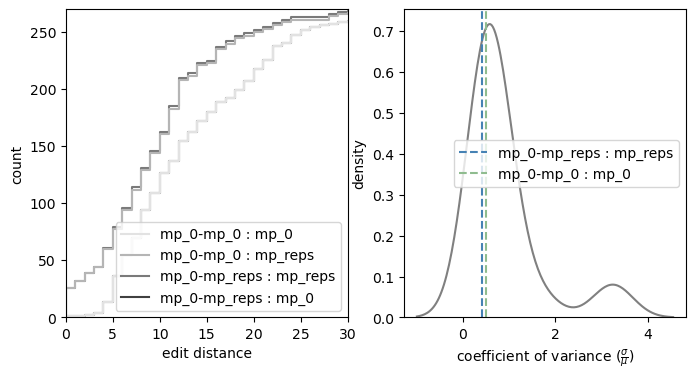

Where do the reads mapped to mp_0 in the mp_0_rps3 mapping get placed in the mp_reps_rps3 mapping?
mp_0	120
mp_37	78
mp_8	36
mp_17	27
mp_29	6


In [14]:
fig, axes = plt.subplots(figsize=(8, 4), ncols=2)

ax = axes[0]
figure_df = list()
figure_df += [bam_df[bam_df.mp_0_mapped].assign(category='mp_0-mp_0 : mp_0').rename(columns={'mp_0_edit_distance':'edit_distance'})]
figure_df += [bam_df[bam_df.mp_0_mapped].assign(category='mp_0-mp_0 : mp_reps').rename(columns={'mp_reps_edit_distance':'edit_distance'})]
figure_df += [bam_df[bam_df.mp_reps_mapped].assign(category='mp_0-mp_reps : mp_reps').rename(columns={'mp_reps_edit_distance':'edit_distance'})] 
figure_df += [bam_df[bam_df.mp_reps_mapped].assign(category='mp_0-mp_reps : mp_0').rename(columns={'mp_0_edit_distance':'edit_distance'})] 
figure_df = pd.concat(figure_df).reset_index()

sns.ecdfplot(figure_df, x='edit_distance', hue='category', stat='count', palette='Grays', ax=ax)
ax.get_legend().set_title('')
ax.set_xlim(xmin=0, xmax=30)
ax.set_ylabel('count')
ax.set_xlabel('edit distance')

ax = axes[1]

figure_df = coverm_dfs['mp_reps'].copy()
sns.kdeplot(figure_df, x='coefficient_of_variance', color='gray')

mp_0_cv = coverm_dfs['mp_0'].coefficient_of_variance.iloc[0] # Coefficient of variance for the reads mapped to mp_0 with the mp_reps reference. 
ax.axvline(x=mp_0_cv, ls='--', color='steelblue', label='mp_0-mp_reps : mp_reps')

mp_0_cv = coverm_dfs['mp_reps'][coverm_dfs['mp_reps'].contig_id == 'mp_0'].coefficient_of_variance.iloc[0] # Coefficient of variance for the reads mapped to mp_0 with the mp_0 reference. 
ax.axvline(x=mp_0_cv, ls='--', color='darkseagreen', label='mp_0-mp_0 : mp_0')

# It seems as though the variability is higher in the mp_0 only sample, suggesting that the full mapping might be slightly better. 

ax.legend()

ax.set_ylabel('density')
ax.set_xlabel(r'coefficient of variance ($\frac{\sigma}{\mu}$)')

fig.tight_layout
plt.show()

# Where are the reads going which had mapped to mp_0 when mp_0 was the only reference?
print('Where do the reads mapped to mp_0 in the mp_0_rps3 mapping get placed in the mp_reps_rps3 mapping?')
for row in bam_df[bam_df.mp_0_mapped].mp_reps_ref_id.value_counts().reset_index().itertuples():
    print(f'{row.mp_reps_ref_id}\t{row.count}')

In [15]:
mp_rps3_df['genome_id'] = mp_rps3_df.cluster_id.apply(lambda cluster_id : f'mp_{cluster_id}')
mp_rps3_df['coverage'] = mp_rps3_df.contig_id.map(mp_rps3_contigs_df.coverage).astype(float)

coverm_df = coverm_dfs['mp_reps'].copy().rename(columns={'contig_id':'genome_id', 'trimmed_mean':'coverage'})
coverm_df['ggkbase_coverage'] = coverm_df.genome_id.map(mp_rps3_df[mp_rps3_df.project_id == 'SR-VP_Bioreactor_N_bot_05_17_2025'].set_index('genome_id').coverage)

coverm_df['coverage_diff'] = np.abs(coverm_df.coverage.astype(float) - coverm_df.ggkbase_coverage.astype(float))
coverm_df['coverage_diff_fraction'] = coverm_df.coverage_diff / coverm_df.coverage

print('Maximum difference between ggKbase and predicted coverages:', coverm_df.coverage_diff.max())
print('Maximum fractional difference between ggKbase and predicted coverages:', coverm_df.coverage_diff_fraction.max())
print('Mean difference between ggKbase and predicted coverages:', coverm_df.coverage_diff.mean())
print('Mean fractional difference between ggKbase and predicted coverages:', coverm_df.coverage_diff_fraction.mean())

# coverm_df[coverm_df.read_count > 0].sort_values('coverage', ascending=False).set_index('genome_id')[['read_count', 'coverage', 'coefficient_of_variance', 'ggkbase_coverage', 'coverage_diff']]

# Inspection of the coverage variance from the bowtie mapping suggests that there might be some problem with reads mapping to only one of many possible valid locations
# e.g. with mp_17, which has a CV of 1.16 and a coverage of >7x despite not being represented by a contig in the sample. To address this, I re-ran bowtie mapping with the -a
# option, so that all valid mappings are reported. The result (including secondary alignments), ended up with coverage values which differed more from ggKbase overall, 
# so I think sticking with only best mappings is a good idea. It could be that this approach is simply more sensitive to small taxonomical differences (which is what
# I wanted anyway).

Maximum difference between ggKbase and predicted coverages: 18.683323
Maximum fractional difference between ggKbase and predicted coverages: 1.0789207998740176
Mean difference between ggKbase and predicted coverages: 4.417436954545455
Mean fractional difference between ggKbase and predicted coverages: 0.3218102996638695


In [18]:
BORG_GENOME_ID_MAP = dict()
BORG_GENOME_ID_MAP['Amber_Borg_SR-VP_9_9_2021_87_5B_1_2m_2_complete'] = 'amber_borg'
BORG_GENOME_ID_MAP['BLACK-SR-VP_26_10_2019_C_40cm_scaffold_23_FINAL_IR'] = 'black_borg'
BORG_GENOME_ID_MAP['Brown_BROWN-SR-VP_26_10_2019_2_100cm_FINAL'] = 'brown_borg'
BORG_GENOME_ID_MAP['Cobalt_Borg_SR-VP_9_9_2021_49_3B_1_65m_curated'] = 'cobalt_borg'
BORG_GENOME_ID_MAP['Green_Borg_SRVP_2020_100_cm_2_FINAL-FINAL'] = 'green_borg'
BORG_GENOME_ID_MAP['Iris_Borg_SR-VP_9_9_2021_87_5B_1_2m_2_curated'] = 'iris_borg'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_141kb_SR-VP_26_10_2020_2_100CM_35_89_complete'] = 'jupiter_mini_borg_1'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_52kb_SR-VP_26_10_2019_1_100cm_35_101_complete'] = 'jupiter_mini_borg_2'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_53kb_SR-VP_9_9_2021_72_4B_1_05m_34_68_near_complete'] = 'jupiter_mini_borg_3'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_54kb_SR-VP_26_10_2019_2_100cm_36_306_complete'] = 'jupiter_mini_borg_4'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_54kb_SRVP19_trench_C_20cm_35_40_near_complete'] = 'jupiter_mini_borg_5'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_59kb_SR-VP_9_9_2021_87_5B_1_2m_33_70_complete'] = 'jupiter_mini_borg_6'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_60kb_SR-VP_26_10_2020_2_100CM_33_14_near_complete'] = 'jupiter_mini_borg_7'
BORG_GENOME_ID_MAP['Jupiter_mini-Borg_60kb_SRVP18_trench_6_60cm_34_58_complete'] = 'jupiter_mini_borg_8'
BORG_GENOME_ID_MAP['Mars_mini-Borg_144kb_SRVP18_trench_6_60cm_32_101_near_complete'] = 'mars_mini_borg'
BORG_GENOME_ID_MAP['Neptune_mini-Borg_131kb_SRVP19_trench_C_20cm_31_38_near_complete'] = 'neptune_mini_borg'
BORG_GENOME_ID_MAP['ORANGE_SR-VP_26_10_2019_2_100cm_FINAL'] = 'orange_borg'
BORG_GENOME_ID_MAP['Ochre_SR-VP_26_10_2020_2_100CM_FINAL_FINAL'] = 'ochre_borg'
BORG_GENOME_ID_MAP['Oxblood_Borg_SR-VP_05_06_2024_N_middle_33_15_complete'] = 'oxblood_borg'
BORG_GENOME_ID_MAP['Pink_Borg_SR-VP_05_06_2024_N_middle_32_23_complete'] = 'pink_borg'
BORG_GENOME_ID_MAP['ROSE_SR-VP_0-2_FINAL'] = 'rose_borg'
BORG_GENOME_ID_MAP['Ruby_Borg_SR-VP_9_9_2021_75_5A_0_95m_2_SR-VP_9_9_2021_87_5B_1_2m_curated'] = 'ruby_borg'
BORG_GENOME_ID_MAP['SR-VP_9_9_2021_65_4B_1_25m_Amethyst_Borg_complete'] = 'amethyst_borg'
BORG_GENOME_ID_MAP['SRVP18_hole-7m-from-trench_1_80cm_scaf_35_ext_315-rev_6-w_terminal_repeats'] = 'sky_borg'
BORG_GENOME_ID_MAP['SRVP18_trench_6_60cm_scaf_214_117_86_FINAL'] = 'purple_borg'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_75kb_SRVP18_trench_6_60cm_34_20_near_complete'] = 'saturn_mini_borg_1'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_82kb_SR-VP_05_06_2024_N_top_32_38_complete'] = 'saturn_mini_borg_2'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_82kb_SR-VP_26_10_2019_2_100cm_33_70_complete'] = 'saturn_mini_borg_3'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_91kb_SR-VP_9_9_2021_87_5B_1_2m_33_14_complete'] = 'saturn_mini_borg_4'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_94kb_SR-VP_9_9_2021_87_5B_1_2m_33_10_near_complete'] = 'saturn_mini_borg_5'
BORG_GENOME_ID_MAP['Saturn_mini-Borg_96kb_SR-VP_9_9_2021_75_5A_0_95m_32_15_complete'] = 'saturn_mini_borg_6'
BORG_GENOME_ID_MAP['Uranus_mini-Borg_51kb_SR-VP_9_9_2021_72_4B_1_05m_34_96_complete'] = 'uranus_mini_borg_1'
BORG_GENOME_ID_MAP['Uranus_mini-Borg_55kb_SR-VP_9_9_2021_81_5A_0_75m_35_16_complete'] = 'uranus_mini_borg_2'
BORG_GENOME_ID_MAP['Venus_mini-Borg_106kb_SRVP18_hole-7m-from-trench_1_80cm_34_23_complete'] = 'venus_mini_borg'
BORG_GENOME_ID_MAP['Viridian_Borg_SR-VP_9_9_2021_75_5A_0_95m_2_curated'] = 'viridian_borg'

In [19]:
# Ideally, I want to try to capture the abundance of all Borgs in the sample (not just use the completed genomes). I would want to BLAST each marker sequence against
# ggKbase and identify contigs with strong matches, and then look for contigs with matches, cluster, and map reads. However, there is no convenient way to 
# BLAST against ggKbase in bulk, and the BLAST search only returns hits for 1000 genes. For now, I will just use the complete genomes.

ece_genomes_df = FASTAFile.from_file('../data/Borg_family_members_contigs.fna').to_df()
ece_genomes_df = ece_genomes_df[ece_genomes_df.index.str.contains('SR-VP|SRVP')].copy() # Get only the Borgs and mini-Borgs identified in SR-VP. 
ece_genomes_df.index = ece_genomes_df.index.map(BORG_GENOME_ID_MAP)
ece_genomes_df['seq'] = ece_genomes_df.seq.str.upper()
ece_genomes_df = pd.concat([ece_genomes_df, FASTAFile.from_file('../data/genomes/bz_0.fasta').to_df(), FASTAFile.from_file('../data/genomes/bz_11.fasta').to_df()])

# For bbmap, want to look at (1) the Methanoperedens rps3 sequences, (2) Betazoid genomes, (3) Borg genomes.
community_df = pd.concat([ece_genomes_df, mp_reps_rps3_df])[['seq']].copy()
FASTAFile.from_df(community_df).write('../data/sr-vp/community.fna')

In [20]:
BOWTIE_CMD = 'bowtie2 -x {index_path} -1 {forward_reads_path} -2 {reverse_reads_path} -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > {output_path}'
BOWTIE_REF_PATH = '/home/philippar/community.fna'
BOWTIE_REF_NAME = os.path.basename(BOWTIE_REF_PATH).replace('.fna', '')
BOWTIE_INDEX_PATH = os.path.join('/home/philippar/bowtie/index/', BOWTIE_REF_NAME)

print(f'bowtie2-build {BOWTIE_REF_PATH} {BOWTIE_INDEX_PATH}') # Only need to build the index once for a given reference. 

for row in SRVP_SAMPLE_METADATA_DF[SRVP_SAMPLE_METADATA_DF.regime == 'Illumina'].itertuples():
    output_path = os.path.join('/home/philippar/bowtie/', f'{row.sample_id}.bam')
    # bowtie2 mapping command for running on biotite. 
    cmd = BOWTIE_CMD.format(ref_path=ref_path, index_path=BOWTIE_INDEX_PATH, forward_reads_path=row.forward_reads_path, reverse_reads_path=row.reverse_reads_path, output_path=output_path)
    print(f'sbatch --wrap "{cmd}"')



bowtie2-build /home/philippar/community.fna /home/philippar/bowtie/index/community
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/community -1 /groups/banfield/sequences/2025/SR-VP_05_06_2024_ck_bottom/raw.d/SR-VP_05_06_2024_ck_bottom_trim_clean.PE.1.fastq.gz -2 /groups/banfield/sequences/2025/SR-VP_05_06_2024_ck_bottom/raw.d/SR-VP_05_06_2024_ck_bottom_trim_clean.PE.2.fastq.gz -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > /home/philippar/bowtie/ch4_bottom_2024_illumina.bam"
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/community -1 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_17_2025/raw.d/SR-VP_Bioreactor_ck_bot_05_17_2025_trim_clean.PE.1.fastq.gz -2 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_17_2025/raw.d/SR-VP_Bioreactor_ck_bot_05_17_2025_trim_clean.PE.2.fastq.gz -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > /home/philippar/bowtie/ch4_bottom_2025_illumina.bam"
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/comm

In [34]:
# Run coverm on all bam outputs. 
bam_paths = [path for path in glob.glob('../data/sr-vp/bowtie/*bam') if not (os.path.basename(path).startswith('mp_'))]

coverm_dfs = dict()
for path in bam_paths:
    output_path = path.replace('.bam', '.tsv')
    sample_id = os.path.basename(path).replace('.bam', '')
    if not os.path.exists(output_path):
        # subprocess.run(f'coverm contig --include-secondary --bam-files {path} --methods length count mean trimmed_mean covered_fraction variance > {output_path}', shell=True, check=True)
        subprocess.run(f'coverm contig --bam-files {path} --methods length count mean trimmed_mean covered_fraction variance > {output_path}', shell=True, check=True)
    try:
        coverm_dfs[sample_id] = load_coverm(output_path)
    except:
        print(f'Error loading coverm output for {path}.')

coverm_df = pd.concat([df.assign(sample_id=sample_id) for sample_id, df in coverm_dfs.items()])
coverm_df['coefficient_of_variance'] = np.where(coverm_df.trimmed_mean > 0, np.sqrt(coverm_df.variance) / coverm_df.trimmed_mean, 0)
# Focus on the Betazoids and Methanoperedens for how. 
coverm_df = coverm_df[coverm_df.contig_id.str.startswith('mp') | coverm_df.contig_id.str.startswith('bz')].copy()

Error loading coverm output for ../data/sr-vp/bowtie/env_175cm_2021_illumina_2.bam.


In [ ]:
MIN_READ_COUNT = 5

filters = dict()
filters['too_few_mapped_reads'] = coverm_df.read_count < MIN_READ_COUNT


coverm_df.sort_values('coefficient_of_variance')

,contig_id,sample_id,covered_fraction,length,mean,read_count,trimmed_mean,variance,coefficient_of_variance
21,mp_11,env_20cm_2018_illumina_3,0.000000,1846.0,0.000000,0.0,0.000000,0.000000,0.000000
34,mp_23,env_20cm_2019_illumina_2,0.000000,1870.0,0.000000,0.0,0.000000,0.000000,0.000000
35,mp_24,env_20cm_2019_illumina_2,0.000000,1843.0,0.000000,0.0,0.000000,0.000000,0.000000
36,mp_25,env_20cm_2019_illumina_2,0.000000,1903.0,0.000000,0.0,0.000000,0.000000,0.000000
37,mp_26,env_20cm_2019_illumina_2,0.000000,1831.0,0.000000,0.0,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
22,mp_12,env_155cm_2021_illumina_2,0.048212,1846.0,0.102594,2.0,0.005236,0.192418,83.783072
25,mp_15,env_95cm_2021_illumina_3,0.047826,1840.0,0.101775,2.0,0.003942,0.190938,110.843401
22,mp_12,env_85cm_2021_illumina_1,0.086674,1846.0,0.097877,2.0,0.001309,0.183925,327.652422
43,mp_31,env_85cm_2021_illumina_2,0.046389,1897.0,0.097310,2.0,0.001271,0.181820,335.366224


In [ ]:
# coverm contig --bam-files /home/philippar/sr-vp/bbmap/*bam --methods length count mean trimmed_mean covered_fraction > /home/philippar/sr-vp/coverm/community.tsv
# coverm contig --include-secondary --bam-files /home/philippar/sr-vp/bbmap/*bam --methods length count mean trimmed_mean covered_fraction > /home/philippar/sr-vp/coverm/community.tsv

In [ ]:


min_covered_bases_fraction = 0.8
min_read_count = 5

STATS_FIELDS = ['file_path', 'format', 'type', 'num_seqs', 'sum_len', 'min_len', 'avg_len', 'max_len']
stats_df = pd.concat([pd.read_csv(path, names=STATS_FIELDS, sep=r'\s+', header=0) for path in glob.glob('../data/sr-vp/stats/*')])
stats_df['file_name'] = stats_df.file_path.apply(os.path.basename)
stats_df['num_seqs'] = stats_df.num_seqs.str.replace(',', '').astype(int)

coverm_df = load_coverm('../data/sr-vp/coverm/community.tsv')

# filters = dict()
# # Want different standards for the ECEs versus the rps3 because (1) there is less risk of multi-mapping to the ECEs and (2) ECE abundance may vary quite a bit relative to a host. 
# filters['ece_with_low_covered_bases_fraction'] = ~coverm_df.contig_id.str.startswith('mp') & (coverm_df.covered_bases_fraction < 0.5) & (coverm_df.read_count < 50)
# filters['mp_rps3_with_low_covered_bases_fraction'] = coverm_df.contig_id.str.startswith('mp') & (coverm_df.covered_bases_fraction < 0.9)
# # coverm_df = apply_filters(filters, coverm_df)
coverm_df


,contig_id,sample_id,covered_fraction,length,mean,read_count,trimmed_mean
0,amber_borg,env_75cm_2021_illumina_3,0.935675,1041317.0,4.924517,24045.0,4.741846
1,amber_borg,env_76cm_2021_illumina,0.003327,1041317.0,0.004034,28.0,0.000000
2,amber_borg,env_80cm_2018_illumina_1,0.832290,1041317.0,1.934736,13986.0,1.828768
3,amber_borg,env_80cm_2022_illumina_2,0.005249,1041317.0,0.008011,44.0,0.000000
4,amber_borg,env_80cm_2022_illumina_3,0.001650,1041317.0,0.002757,3.0,0.000000
...,...,...,...,...,...,...,...
2200,viridian_borg,no3_bottom_2025_illumina,0.000000,673463.0,0.000000,0.0,0.000000
2201,viridian_borg,no3_middle_2024_illumina,0.000742,673463.0,0.000743,2.0,0.000000
2202,viridian_borg,no3_middle_2025_illumina,0.000030,673463.0,0.000030,1.0,0.000000
2203,viridian_borg,no3_top_2024_illumina,0.000030,673463.0,0.000030,1.0,0.000000


In [ ]:
# First would like to check the coverm/bbmap-predicted coverages against the ones reported in ggkbase. 
GGKBASE_CONTIG_ID_TO_GENOME_ID_MAP = {'_'.join(ggkbase_gene_id.split('_')[:-1]):f'mp_{cluster_id}' for ggkbase_gene_id, cluster_id in cluster_id_map.items()} # Only the Methanoperedens.

GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP = SRVP_SAMPLE_METADATA_DF[~SRVP_SAMPLE_METADATA_DF.ggkbase_sample_id.isnull()].set_index('ggkbase_sample_id').sample_id.to_dict()
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP = {ggkbase_sample_id.replace('.', '_'):sample_id for ggkbase_sample_id, sample_id in GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP.items()}
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_0-2'] = 'env_2cm_2017_illumina' # 'SR-VP_0-2cm_Biohub_180515'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_4-6'] = 'env_6cm_2017_illumina' # 'SR-VP_4-6cm_Biohub_180515'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_9_9_2021_72_4B_1_05m_2_METASPADES'] = 'env_105cm_2021_illumina_2'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_9_9_2021_75_5A_0_95m_2_METASPADES'] = 'env_95cm_2021_illumina_2'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_9_9_2021_81_5A_0_75m_2_METASPADES'] = 'env_75cm_2021_illumina_2'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SR-VP_9_9_2021_87_5B_1_2m_2_METASPADES'] = 'env_120cm_2021_illumina_2'
GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['Methanoperedens_44_19-type_SR-VP_26_10_2019_1_100cm_part'] = 'env_100cm_2019_illumina_1'
# GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SRVP19_trench_C_20cm_viral_megahit'] Missing
# GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP['SRVP19_trench_A_40cm-2_viral_idba'] Missing


get_ggkbase_sample_id = lambda ggkbase_contig_id : ggkbase_contig_id.split('_scaffold_')[0] if ('scaffold' in ggkbase_contig_id) else '_'.join(ggkbase_contig_id.split('_')[:-1])

mp_rps3_contigs_df = load_mp_rps3_contigs()[['coverage']]
mp_rps3_contigs_df = mp_rps3_contigs_df[~mp_rps3_contigs_df.index.str.contains('PACBIO', case=False)].copy()
mp_rps3_contigs_df['ggkbase_sample_id'] = [get_ggkbase_sample_id(ggkbase_contig_id) for ggkbase_contig_id in mp_rps3_contigs_df.index]
mp_rps3_contigs_df['sample_id'] = mp_rps3_contigs_df.ggkbase_sample_id.map(GGKBASE_SAMPLE_ID_TO_SAMPLE_ID_MAP)
mp_rps3_contigs_df['contig_id'] = mp_rps3_contigs_df.index.map(GGKBASE_CONTIG_ID_TO_GENOME_ID_MAP)
mp_rps3_contigs_df = mp_rps3_contigs_df.reset_index(names=['ggkbase_contig_id'])
mp_rps3_contigs_df = mp_rps3_contigs_df.merge(coverm_df, on=['sample_id', 'contig_id'], how='inner') #, validate='one_to_one')


In [ ]:
mp_rps3_contigs_df.value_counts(['contig_id', 'sample_id'])
mp_rps3_contigs_df[(mp_rps3_contigs_df.contig_id == 'mp_0') & (mp_rps3_contigs_df.sample_id == 'env_105cm_2021_illumina_2')]

,ggkbase_contig_id,coverage,ggkbase_sample_id,sample_id,contig_id,covered_fraction,length,mean,read_count,trimmed_mean


In [ ]:
mp_rps3_contigs_df['coverage_diff'] = np.abs(mp_rps3_contigs_df.trimmed_mean - pd.to_numeric(mp_rps3_contigs_df.coverage))
mp_rps3_contigs_df['coverage_diff_fraction'] = mp_rps3_contigs_df.coverage_diff / mp_rps3_contigs_df.trimmed_mean

In [ ]:

mp_rps3_contigs_df['coverage'] = mp_rps3_contigs_df.coverage.astype(float)
mp_rps3_contigs_df.sort_values('coverage')

,ggkbase_contig_id,coverage,ggkbase_sample_id,sample_id,contig_id,covered_fraction,length,mean,read_count,trimmed_mean,coverage_diff,coverage_diff_fraction
18,SR-VP_9_9_2021_75_5A_0_95m_2_METASPADES_scaffo...,0.0,SR-VP_9_9_2021_75_5A_0_95m_2_METASPADES,env_95cm_2021_illumina_2,mp_10,0.267279,1852.0,0.932432,8.0,0.706919,0.706919,1.000000
17,SR-VP_9_9_2021_75_5A_0_95m_2_METASPADES_scaffo...,0.0,SR-VP_9_9_2021_75_5A_0_95m_2_METASPADES,env_95cm_2021_illumina_2,mp_2,0.997878,1885.0,30.342940,330.0,30.927704,30.927704,1.000000
24,SR-VP_07_25_2022_A1_95cm_scaffold_194604,1.0,SR-VP_07_25_2022_A1_95cm,env_95cm_2022_illumina,mp_4,0.221402,1897.0,0.429307,0.0,0.316592,0.683408,2.158635
27,SR-VP_11_27_2022_S1_80cm_scaffold_16780,1.0,SR-VP_11_27_2022_S1_80cm,env_80cm_2022_illumina_3,mp_3,0.867483,1879.0,4.639676,36.0,4.486834,3.486834,0.777126
21,SR-VP_07_25_2022_A1_90cm_scaffold_262255,2.0,SR-VP_07_25_2022_A1_90cm,env_90cm_2022_illumina_1,mp_13,0.000000,1897.0,0.000000,0.0,0.000000,2.000000,inf
...,...,...,...,...,...,...,...,...,...,...,...,...
60,SR-VP_Bioreactor_N_mid_05_17_2025_scaffold_1256,49.0,SR-VP_Bioreactor_N_mid_05_17_2025,no3_middle_2025_illumina,mp_1,0.204006,1897.0,1.441328,11.0,1.054037,47.945963,45.487936
59,SR-VP_Bioreactor_N_mid_05_17_2025_scaffold_2,57.0,SR-VP_Bioreactor_N_mid_05_17_2025,no3_middle_2025_illumina,mp_8,0.000000,1876.0,0.000000,0.0,0.000000,57.000000,inf
0,SRVP18_hole-7m-from-trench_1_80cm_scaffold_15432,87.0,SRVP18_hole-7m-from-trench_1_80cm,env_80cm_2018_illumina_1,mp_0,0.993531,1855.0,28.769500,356.0,28.541368,58.458632,2.048207
63,SR-VP_Bioreactor_N_mid_05_17_2025_scaffold_12265,157.0,SR-VP_Bioreactor_N_mid_05_17_2025,no3_middle_2025_illumina,mp_2,1.000000,1885.0,128.068010,920.0,129.441450,27.558550,0.212904


In [ ]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, leaves_list

# Clustering based on correlation does not work well, I think because of how many zeros there are. Jaccard is preferable because it 
# ignores instances where both samples are zero. 
def get_order(values, index=None, metric='jaccard'):
    '''Perform agglomerative hierarchical clustering on the input features, and sort the corresponding index according to the resulting dendogram.'''
    # The output of linkage has one row per merge, which will be (n - 1) where n is the number of observations (len(index)). 
    # The columns of Z are (1) the index of the  first cluster merged, (2) the index of the second cluster merged, (3) the distance between the merged clusters, 
    # (4) the number of observations in the new cluster. 
    Z = linkage(pdist(values, metric=metric), method='average')
    order = leaves_list(Z) # Reads the linkage matrix and outputs the original observations ordered according to hierarchical similarity. 
    return index[order]


In [ ]:
# Conserned about samples where coverage should be higher, possibly issues with multi-mapping. There is at least one instance where
# mp_10 rps3 registers as very low coverage in SR-VP_Bioreactor_N_bot_05_17_2025, but the gene is a 99% match for SR-VP_Bioreactor_N_bot_05_17_2025_scaffold_303, 
# which has 30x coverage. I suspect the issue is with multimapping and/or ambiguous reads not being mapped. 

In [ ]:
# min_num_samples = 3

# figure_df = coverm_df.copy()
# figure_df = figure_df[figure_df.contig_id.str.startswith('mp') | figure_df.contig_id.str.startswith('bz')].copy()
# figure_df = figure_df.pivot(index='contig_id', columns='sample_id', values='rpkm').fillna(0)
# # figure_df =  pd.DataFrame(np.where(figure_df < min_coverage, 0, 1), index=figure_df.index, columns=figure_df.columns)
# # figure_df[figure_df < min_coverage] = 0

# # print(f'Samples with no organism over the {min_coverage}x detection limit:', ' '.join(figure_df.columns[figure_df.T.sum(axis=1) == 0]))
# print(f'Number of organisms not detected in at least {min_num_samples} samples:', ((figure_df > 0).sum(axis=1) < min_num_samples).sum())
# # print(f'Organisms not found in at least {min_num_samples} samples:', ' '.join(figure_df[figure_df.sum(axis=1) < min_num_samples].index))

# figure_df = figure_df[(figure_df > 0).sum(axis=1) >= min_num_samples].copy()
# figure_df = np.log1p(figure_df)

# genome_order = get_order((figure_df.values > 0).astype(int), index=figure_df.index.values)
# sample_order = get_order((figure_df.values > 0).astype(int).T, index=figure_df.columns.values)
# # cmap = ListedColormap(['white', 'darkseagreen', 'steelblue'])
# # Replace values according to organism category (ECE or Methanoperedens). 
# # figure_df[figure_df.index.str.startswith('mp')] =  figure_df[figure_df.index.str.startswith('mp')].replace(1, 2)
# # figure_df[~figure_df.index.str.startswith('mp')] =  figure_df[~figure_df.index.str.startswith('mp')].replace(1, 1)

# fig, ax = plt.subplots(figsize=np.array(figure_df.shape)[::-1] / 3)
# figure_df = figure_df.loc[genome_order, sample_order]
# figure_df[figure_df == 0] = np.nan 

# sns.heatmap(figure_df, cbar=False, cmap='Blues', linecolor='white', linewidths=1)
# ax.set_ylabel('')
# ax.set_xlabel('')
# plt.show()

# # There should be a Methanoperedens with around 6x coverage, SR-VP_05_06_2024_N_bottom, in SR-VP_05_06_2024_N_bottom. 
# # SR-VP_05_06_2024_N_bottom_Black_host_Methanoperedens_44_7
# # Which one is the confirmed Betazoid host? Seems to be mp_10 (SRVP18_trench_2_45cm_scaffold_74960_2 representative, 99% match to SR-VP_Bioreactor_ck_bot_05_17_2025_Black_host_Methanoperedens_44_40)

In [ ]:
GGKBASE_ORGANISM_INFO_FIELDS = ['bin_numerical_id', 'bin_id', 'bin_original_id', 'project_id', 'project_group', 'taxonomy', 'note', 'bin_size', 'gc_percent', 'coverage', 'num_contigs', 'num_features', 'longest_contig_size', 'num_ribosomal_proteins', 'num_ribosomal_multiple','num_bscg', 'num_bscg_multiple', 'num_ascg', 'num_ascg_multiple', 'curation_status', 'completion_status']
mp_srvp_organism_info_df = pd.read_csv('../data/sr-vp/MpSRVP_organism_info.tsv', sep='\t', names=GGKBASE_ORGANISM_INFO_FIELDS, header=0, index_col=None)
mp_srvp_organism_info_df['num_rps3'] = mp_srvp_organism_info_df.bin_id.map(mp_srvp_rps3_df.groupby('bin_id').size())
mp_srvp_organism_info_df['num_rps3'] = mp_srvp_organism_info_df.num_rps3.fillna(0)


In [ ]:
# In order to identify best matches for potential Borg and Methanoperedens genes on the Betazoids, I need a reliable set of reference genes to BLAST against. 
# If horizontal gene transfer did occur, it likely occurred between a Methanoperedens within an SR-VP sample. 
#   (1) Obtain all genes from the complete and semi-complete Methanoperedens genomes in the MpSRVP project. 
#   (2) BLAST all genes against ggKbase on biotite. 
#       blastn -db /shared/db/.blastdb/ggkbase/11082017/all_genes/all_genes_11082017.fna -out MpSRVP_genes-ggkbase.tsv -query /home/philippar/betazoid/sr-vp/MpSRVP_genes.fna -outfmt "6 qseqid sseqid pident length evalue bitscore qstart qend sstart send sseq qseq" -max_hsps 1 -max_target_seqs 100
#   (3) Obtain all BLAST hits passing some identity and alignment thresholds, and (possibly) filter for SR-VP-derived genes. Use these genes to construct a BLAST database of Methanoperedens genes.

# Another option would be to use the GTDB Methanoperedens genomes

In [ ]:
# mask = coverm_df.contig_id.str.startswith('mp')
# print('Number of Methanoperedens rps3 mapped:', coverm_df[mask].contig_id.nunique())
# print(f'Number of Methanoperedens rps3 with > {min_read_count} mapped reads in any sample:', coverm_df[mask & (coverm_df.read_count > min_read_count)].contig_id.nunique())
# print(f'Number of Methanoperedens rps3 with covered bases fraction > {min_covered_bases_fraction} in any sample:', coverm_df[mask & (coverm_df.covered_bases_fraction > min_covered_bases_fraction)].contig_id.nunique())

# mp_coverm_df = coverm_df[mask].copy()
# mp_coverm_df = mp_coverm_df[mp_coverm_df.covered_bases_fraction > min_covered_bases_fraction].copy()
# mp_coverm_df['log_rpkm'] = [np.log(rpkm) if (rpkm > 0) else np.nan for rpkm in mp_coverm_df.rpkm]

# mask = ~coverm_df.contig_id.str.startswith('mp')
# print('\nNumber of ECE genomes mapped:', coverm_df[mask].contig_id.nunique())
# print(f'Number of ECE genomes with > {min_read_count} mapped reads in any sample:', coverm_df[mask & (coverm_df.read_count > min_read_count)].contig_id.nunique())
# print(f'Number of ECE genomes with covered bases fraction > {min_covered_bases_fraction} in any sample:', coverm_df[mask & (coverm_df.covered_bases_fraction > min_covered_bases_fraction)].contig_id.nunique())

# ece_coverm_df = coverm_df[mask].copy()
# ece_coverm_df = ece_coverm_df[ece_coverm_df.covered_bases_fraction > min_covered_bases_fraction].copy()

In [ ]:
# kmeans = KMeans(n_clusters=5)
# kmeans.fit(figure_df.values)
# idxs = np.argsort(kmeans.labels_)
# genome_order = figure_df.index[np.argsort(idxs)]
# genome_cluster_labels = kmeans.labels_[idxs]

# kmeans = KMeans(n_clusters=3)
# kmeans.fit(figure_df.values.T)
# idxs = np.argsort(kmeans.labels_)
# sample_order = figure_df.columns[np.argsort(idxs)]
# sample_cluster_labels = kmeans.labels_[idxs]

# from matplotlib.patches import Rectangle

# genome_clusters = list(np.unique(genome_cluster_labels, return_index=True)[-1]) + [len(genome_cluster_labels)]
# width = len(figure_df.columns)
# for i in range(len(genome_clusters) - 1):
#     start, stop = genome_clusters[i], genome_clusters[i + 1]
#     height = stop - start
#     ax.add_patch(Rectangle((0, start), width, height, fill=False, edgecolor='black', linewidth=3))

In [ ]:

# # mmseqs easy-cluster /home/prichter/Documents/banfield/betazoid/data/sr-vp/mp_rps3.fna /home/prichter/Documents/banfield/betazoid/data/sr-vp/mp_rps3 /home/prichter/Documents/banfield/betazoid/data/tmp --dbtype 2 --min-seq-id 0.98 --cov-mode 5 -c 0.9
# mp_rps3_cluster_df = pd.read_csv('../data/sr-vp/mp_rps3_cluster.tsv', sep='\t', names=['rep_gene_id', 'gene_id'])
# mp_rps3_cluster_df['cluster_id'] = pd.factorize(mp_rps3_cluster_df.rep_gene_id)[0] + 1
# mp_rps3_cluster_df['cluster_size'] = mp_rps3_cluster_df.cluster_id.map(mp_rps3_cluster_df.groupby('cluster_id').size())
# mp_rps3_cluster_df['project_id'] = mp_rps3_cluster_df.gene_id.map(mp_rps3_df.project_id)
# mp_rps3_cluster_df = mp_rps3_cluster_df.set_index('gene_id')

# mp_rps3_df = mp_rps3_df.drop(columns=mp_rps3_cluster_df.columns, errors='ignore')
# mp_rps3_df = mp_rps3_df.merge(mp_rps3_cluster_df, left_index=True, right_index=True)
# mp_rps3_df = mp_rps3_df.sort_values('length', ascending=False) # So the longest gene in each cluster is retained.

# MP_GENOME_ID_MAP = {rep_gene_id:f'mp_{i + 1}' for i, rep_gene_id in enumerate(mp_rps3_cluster_df.rep_gene_id.unique())}
# mp_rps3_reps_df = mp_rps3_df.drop_duplicates('cluster_id')
# mp_rps3_reps_df['genome_id'] = mp_rps3_reps_df.cluster_id.apply(lambda cluster_id : f'mp_{cluster_id}')
# mp_rps3_reps_df = mp_rps3_reps_df.set_index('genome_id')

# FASTAFile.from_df(mp_rps3_reps_df).write('../data/sr-vp/mp_rps3_reps.fna')

# print('Number of Methanoperedens rps3 (clustered at 98% identity):', mp_rps3_cluster_df.rep_gene_id.nunique())
# print('Length of shortest Methanoperedens rps3:', mp_rps3_df.length.min())
# print('Length of shortest representative Methanoperedens rps3:', mp_rps3_reps_df.length.min())


In [ ]:
# def load_bin_analysis(path:str, gene_name='rps3', drop=['SR-VP_05_06_2024_coassembly']):
#     '''Convert bin analysis output from wide-form to long-form data. Note that an rps3 sequence observed in multiple samples is identified according to a 
#     99 percent identity grouping.
#     column 0 : Protein identifier in the form {gene_id} | {bin_id}. The gene ID specified here is repeated under the corresponding sample column, so this can be excluded.
#     column 1 : Taxonomy, which is not very informative, as well as the confidence of the assignment.
#     column 2+ : Column names are the ggKbase sample ID, and entries are of the form "{gene_id} in {bin_id} ({bin_coverage}x) with contig info - feature cnt: {num_genes} | size: {contig_length} | cov: {contig_coverage}x | gc: {contig_gc_percent}%
#     '''
#     df = pd.read_csv(path, sep='\t').drop(columns=drop)
#     print(f'load_bin_analysis: Loaded {len(df)} entries from {path}.')
#     df = df.iloc[:, 1:] # Ignore the first column.
#     df = df.rename(columns={'phylogeny winner':'taxonomy'})
#     sample_ids = [col for col in df.columns if (col != 'taxonomy')]
    
#     contig_info_pattern = r'feature cnt: (?P<num_genes>[\d]+) \| size: (?P<contig_length>[\d]+) \| cov: (?P<coverage>[^\s]+)x \| gc: (?P<gc_percent>[^\s]+)%'
#     pattern = fr'(?P<ggkbase_gene_id>[^\s]+) in (?P<ggkbase_bin_id>[^\s]+) \((?P<bin_coverage>[^x]+)x\) with contig info - {contig_info_pattern}'
    
#     df_ = list()    
#     for i, row in df.iterrows():
#         for sample_id in sample_ids:
#             row_ = {'gene_id':f'{gene_name}_{i}', 'sample_id':sample_id, 'taxonomy':row['taxonomy']}
#             if type(row[sample_id]) == float: # Check if the value is empty. 
#                 row_.update({'coverage':0, 'contig_info':None, 'ggkbase_gene_id':None}) 
#             else:
#                 row_.update(re.search(pattern, row[sample_id]).groupdict())
#             df_.append(row_)
#     df_ = pd.DataFrame(df_)
#     df_['coverage'] = df_['coverage'].astype(float)
#     return df_


In [ ]:
# singleton_gene_ids = [gene_id for cluster in clusters if (len(cluster) == 1) for gene_id in cluster]
# mp_rps3_align_df = pd.read_csv('../data/sr-vp/mmseqs/mp_rps3_extended.tsv', sep='\t', names=MMSEQS_SEARCH_FIELDS.split(','))
# mp_rps3_align_df['query_is_singleton'] = mp_rps3_align_df['query'].isin(singleton_gene_ids)
# mp_rps3_align_df['target_is_singleton'] = mp_rps3_align_df['target'].isin(singleton_gene_ids)

# filters = dict()
# filters['self_alignment'] = mp_rps3_align_df['query'] == mp_rps3_align_df['target']
# filters['not_a_singleton_cluster'] = ~(mp_rps3_align_df['query'].isin(singleton_gene_ids) | mp_rps3_align_df['target'].isin(singleton_gene_ids))
# filters['both_sequences_are_singleton'] = (mp_rps3_align_df.query_is_singleton & mp_rps3_align_df.target_is_singleton)

# mp_rps3_align_df = apply_filters(filters, mp_rps3_align_df)
# mp_rps3_align_df = mp_rps3_align_df.sort_values('fident', ascending=False)
# mp_rps3_align_df['singleton_id'] = [row.target if (row.target in singleton_gene_ids) else row.query for row in mp_rps3_align_df.itertuples()]
# mp_rps3_align_df = mp_rps3_align_df.drop_duplicates('singleton_id')